<a href="https://colab.research.google.com/github/Ashish-Ved/employee-attrition-predictor/blob/main/employee_attrition_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install any missing libraries (Colab has most pre-installed)
!pip install imbalanced-learn xgboost --quiet

# Import everything we'll need for the whole project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
import urllib.request

#url = "https://raw.githubusercontent.com/dsaks/hr-analytics/master/WA_Fn-UseC_-HR-Employee-Attrition.csv"
#urllib.request.urlretrieve(url, "hr_attrition.csv")

df = pd.read_csv("hr_attrition.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 1470 rows, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Shape and column names
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [4]:
# Data types and null check
print(df.info())
print("\nNull values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
# What does our target column look like?
print(df['Attrition'].value_counts())
print("\nAttrition rate:", round(df['Attrition'].value_counts(normalize=True)['Yes'] * 100, 1), "%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1 %


In [6]:
# Quick statistical summary
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)

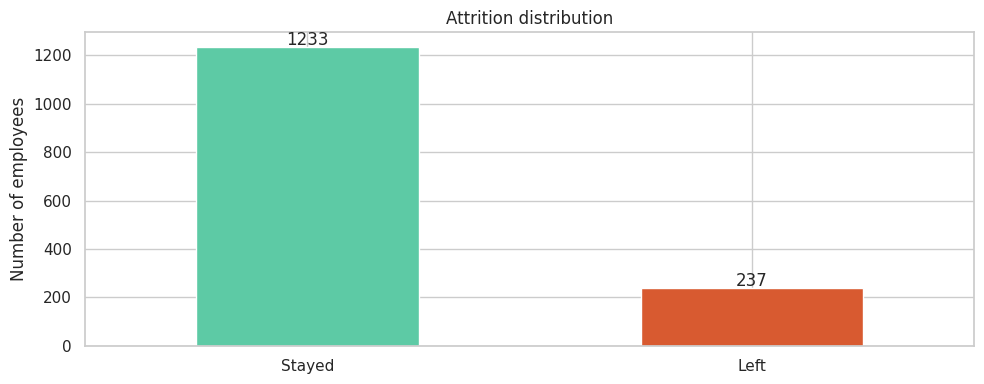

In [9]:
fig, ax = plt.subplots()
colors = ["#5DCAA5", "#D85A30"]
df["Attrition"].value_counts().plot(kind="bar", color=colors, ax=ax, edgecolor="white")
ax.set_title("Attrition distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of employees")
ax.set_xticklabels(["Stayed", "Left"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height() + 10), ha="center")
plt.tight_layout()
plt.show()

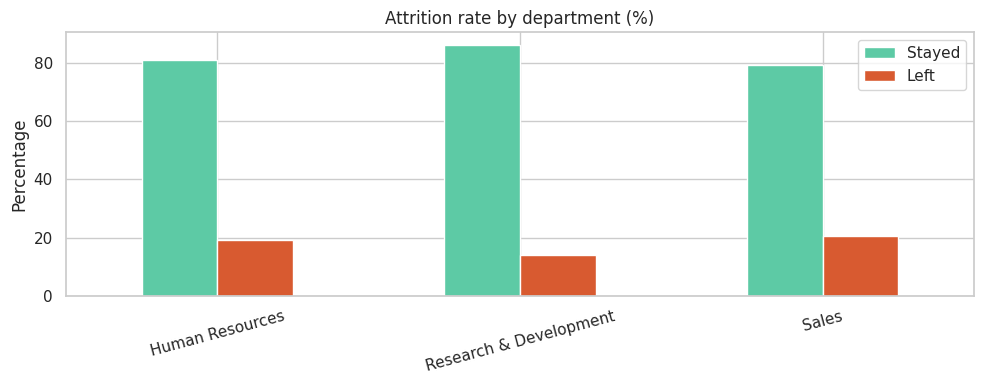

In [10]:
# attrition by department
dept_attr = df.groupby("Department")["Attrition"].value_counts(normalize=True).unstack() * 100

dept_attr.plot(kind="bar", color=["#5DCAA5", "#D85A30"], edgecolor="white")
plt.title("Attrition rate by department (%)")
plt.xlabel("")
plt.ylabel("Percentage")
plt.xticks(rotation=15)
plt.legend(["Stayed", "Left"])
plt.tight_layout()
plt.show()

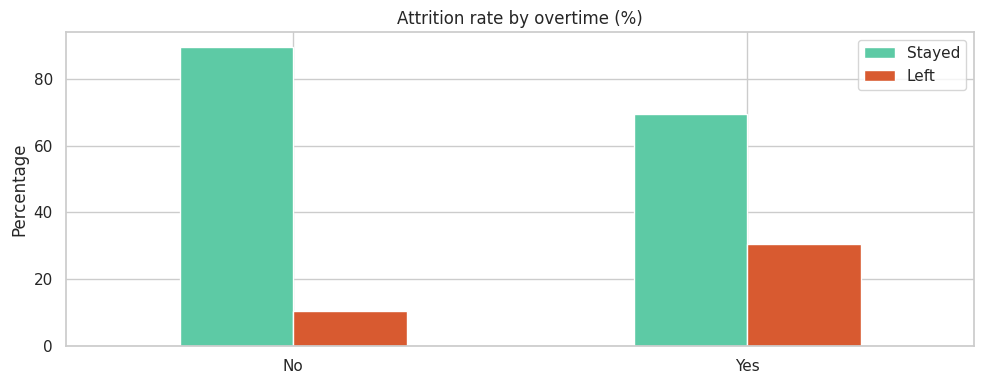

In [11]:
#Attrition by OverTime (one of the strongest signals)
ot = df.groupby("OverTime")["Attrition"].value_counts(normalize=True).unstack() * 100

ot.plot(kind="bar", color=["#5DCAA5", "#D85A30"], edgecolor="white")
plt.title("Attrition rate by overtime (%)")
plt.xlabel("")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Left"])
plt.tight_layout()
plt.show()

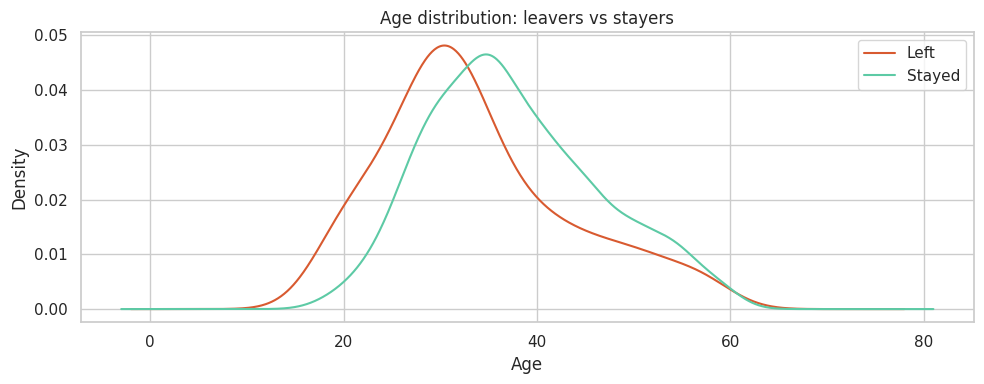

In [12]:
#  Age distribution: leavers vs stayers
fig, ax = plt.subplots()
df[df["Attrition"] == "Yes"]["Age"].plot(kind="kde", ax=ax, color="#D85A30", label="Left")
df[df["Attrition"] == "No"]["Age"].plot(kind="kde", ax=ax, color="#5DCAA5", label="Stayed")
ax.set_title("Age distribution: leavers vs stayers")
ax.set_xlabel("Age")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1453/3005670020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette={"No": "#5DCAA5", "Yes": "#D85A30"}, ax=ax)


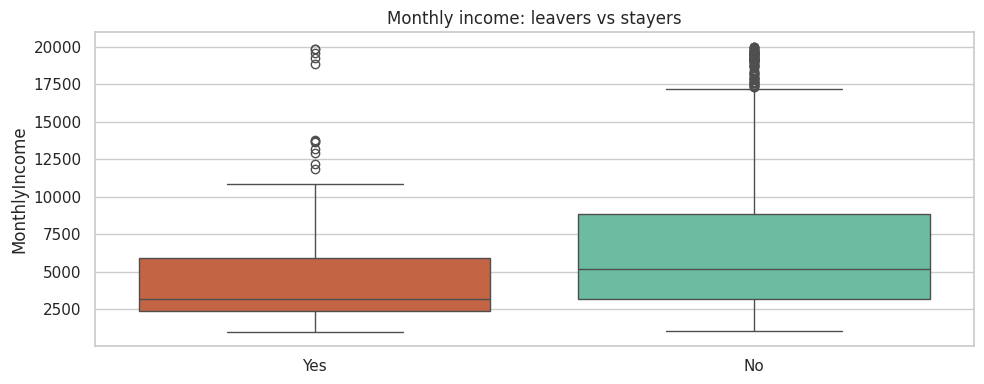

In [13]:
#Monthly income vs attrition (box plot)
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette={"No": "#5DCAA5", "Yes": "#D85A30"}, ax=ax)
ax.set_title("Monthly income: leavers vs stayers")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

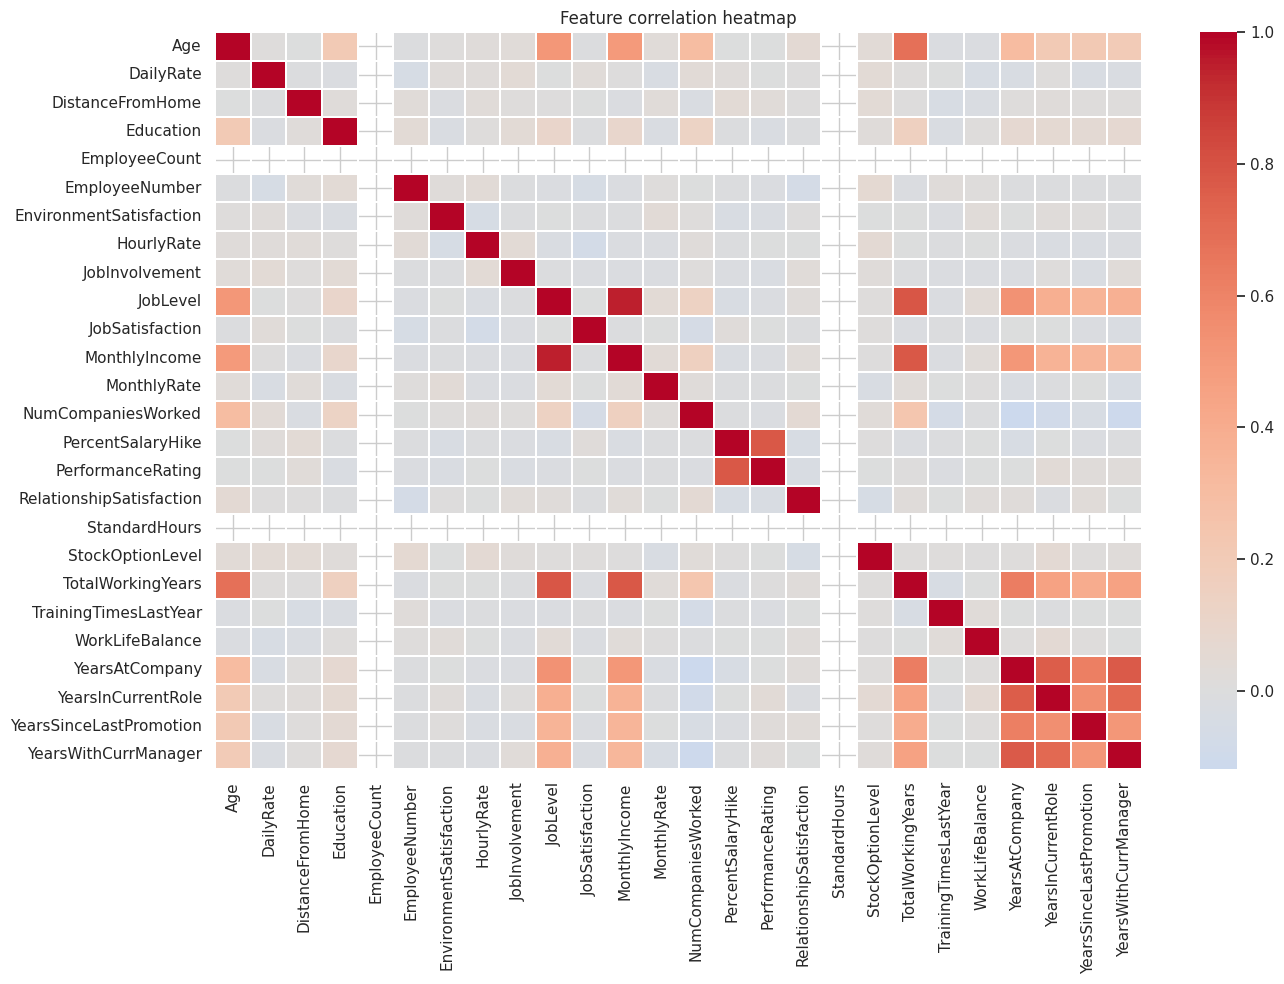

In [14]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, fmt=".1f")
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

In [15]:
#Two useless columns to drop now
# These columns have the same value for every row — zero information
print(df["EmployeeCount"].unique())   # always 1
print(df["StandardHours"].unique())   # always 80
print(df["Over18"].unique())          # always Y

# Drop them
df.drop(columns=["EmployeeCount", "StandardHours", "Over18"], inplace=True)
print("Dropped 3 useless columns. New shape:", df.shape)

[1]
[80]
['Y']
Dropped 3 useless columns. New shape: (1470, 32)


In [16]:
# feature engineering
#Separate target and drop the EmployeeNumber (it's just an ID)

# EmployeeNumber is just a row ID — no predictive value
df.drop(columns=["EmployeeNumber"], inplace=True)

# Separate target variable
X = df.drop(columns=["Attrition"])
y = df["Attrition"].map({"Yes": 1, "No": 0})  # convert to 0/1

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (1470, 30)
Target distribution:
 Attrition
0    1233
1     237
Name: count, dtype: int64


In [17]:
#  Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}):", cat_cols)
print(f"\nNumeric columns ({len(num_cols)}):", num_cols)

Categorical columns (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numeric columns (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [18]:
# Encode categorical columns
# Binary columns — label encode (just 0 and 1)
binary_cols = [col for col in cat_cols if X[col].nunique() == 2]
multi_cols  = [col for col in cat_cols if X[col].nunique() > 2]

print("Binary encode:", binary_cols)
print("One-hot encode:", multi_cols)

le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# One-hot encode multi-class columns
X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

print("\nShape after encoding:", X.shape)
print("Sample columns:", X.columns.tolist()[:10])

Binary encode: ['Gender', 'OverTime']
One-hot encode: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

Shape after encoding: (1470, 44)
Sample columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction']


In [19]:
# Scale numeric features
scaler = StandardScaler()

# Only scale the original numeric columns (not the new one-hot columns)
num_cols_present = [col for col in num_cols if col in X.columns]
X[num_cols_present] = scaler.fit_transform(X[num_cols_present])

print("Scaling done.")
print("Sample of scaled values:")
print(X[num_cols_present[:3]].head(3))

Scaling done.
Sample of scaled values:
        Age  DailyRate  DistanceFromHome
0  0.446350   0.742527         -1.010909
1  1.322365  -1.297775         -0.147150
2  0.008343   1.414363         -0.887515


In [20]:
# Train/test split BEFORE applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps the 16% ratio in both splits
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts())

Train size: (1176, 44)
Test size:  (294, 44)

Train target distribution:
 Attrition
0    986
1    190
Name: count, dtype: int64


In [21]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 986, 1: 190}
After SMOTE:  {0: 986, 1: 986}


In [22]:
#  Quick sanity check
print("=== Sanity Check ===")
print(f"X_train_bal shape : {X_train_bal.shape}")
print(f"X_test shape      : {X_test.shape}")
print(f"Any nulls in train: {pd.DataFrame(X_train_bal).isnull().sum().sum()}")
print(f"Any nulls in test : {X_test.isnull().sum().sum()}")
print(f"Features used     : {X.shape[1]}")

=== Sanity Check ===
X_train_bal shape : (1972, 44)
X_test shape      : (294, 44)
Any nulls in train: 0
Any nulls in test : 0
Features used     : 44


In [23]:
# # Define all three models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Train each one on the SMOTE-balanced training data
trained_models = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model
    print(f"✓ {name} trained")

✓ Logistic Regression trained
✓ Random Forest trained


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:25:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✓ XGBoost trained


In [24]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score

results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {"F1 Score": round(f1, 3), "ROC-AUC": round(auc, 3)}

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))


  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.89      0.91      0.90       247
        Left       0.48      0.43      0.45        47

    accuracy                           0.83       294
   macro avg       0.68      0.67      0.68       294
weighted avg       0.83      0.83      0.83       294


  Random Forest
              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.90       247
        Left       0.41      0.15      0.22        47

    accuracy                           0.83       294
   macro avg       0.63      0.55      0.56       294
weighted avg       0.78      0.83      0.79       294


  XGBoost
              precision    recall  f1-score   support

      Stayed       0.87      0.98      0.92       247
        Left       0.67      0.26      0.37        47

    accuracy                           0.86       294
   macro avg       0.77      0.62      0.65       294
weighted avg       0.84

In [25]:
results_df = pd.DataFrame(results).T
print(results_df.sort_values("F1 Score", ascending=False))

                     F1 Score  ROC-AUC
Logistic Regression     0.449    0.785
XGBoost                 0.369    0.757
Random Forest           0.219    0.724


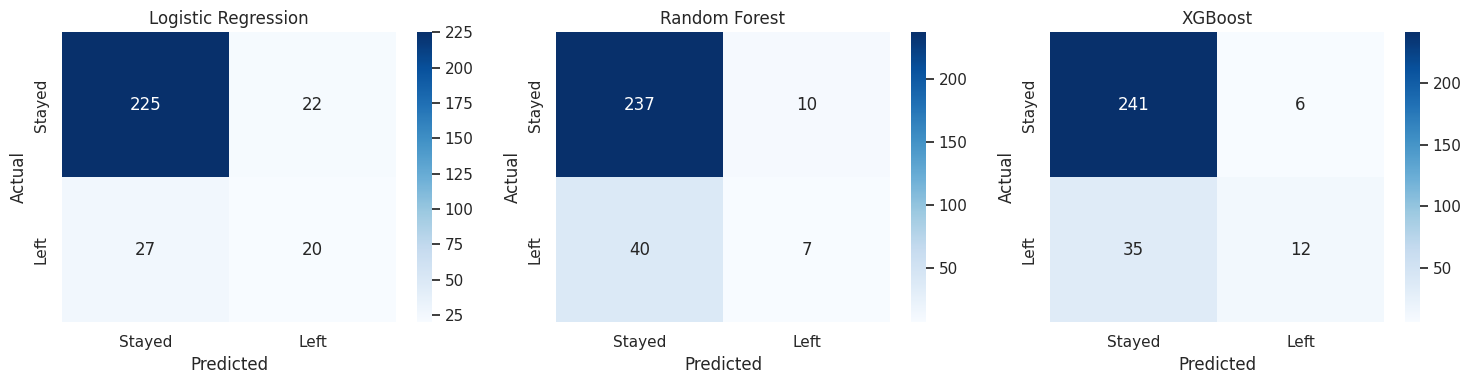

In [26]:
# Confusion matrices for all three
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Stayed", "Left"],
                yticklabels=["Stayed", "Left"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

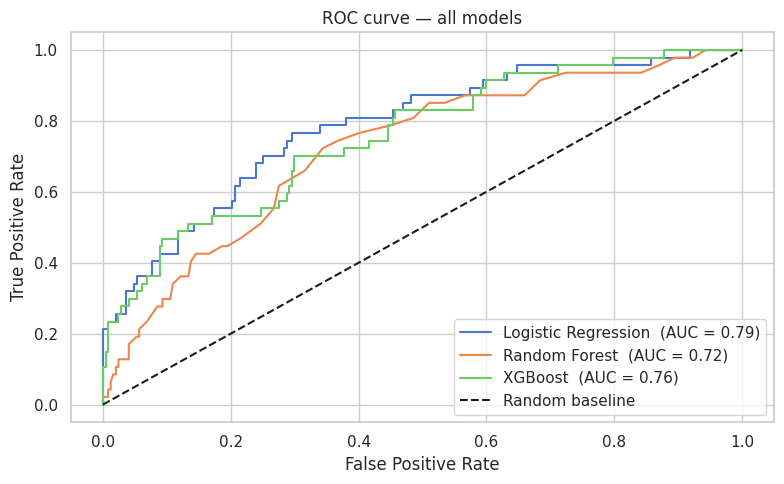

In [27]:
# ROC curve (all three on one chart)
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 5))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — all models")
plt.legend()
plt.tight_layout()
plt.show()

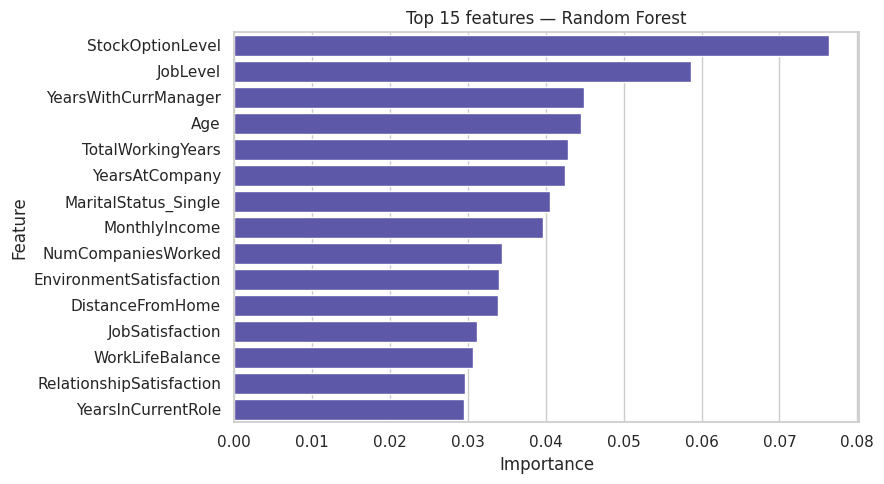

In [28]:
# Feature importance (Random Forest)
rf_model = trained_models["Random Forest"]
importance_df = pd.DataFrame({
    "Feature":   X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", color="#534AB7")
plt.title("Top 15 features — Random Forest")
plt.tight_layout()
plt.show()

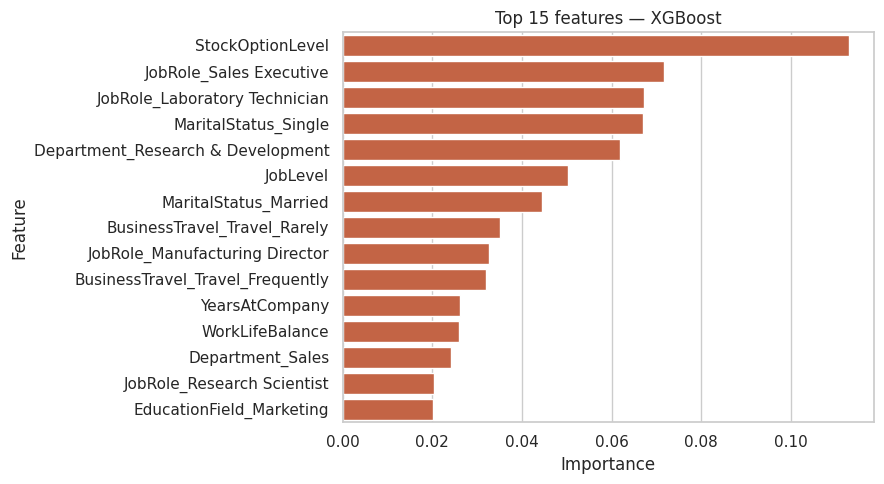

In [29]:
#  Feature importance (XGBoost)
xgb_model = trained_models["XGBoost"]
xgb_importance = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 5))
sns.barplot(data=xgb_importance, x="Importance", y="Feature", color="#D85A30")
plt.title("Top 15 features — XGBoost")
plt.tight_layout()
plt.show()

In [30]:
# Generate a Client-Ready Findings Report
# Find best model by F1
best_name = max(results, key=lambda k: results[k]["F1 Score"])
best_model = trained_models[best_name]
best_f1    = results[best_name]["F1 Score"]
best_auc   = results[best_name]["ROC-AUC"]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

tn, fp, fn, tp = cm.ravel()
attrition_caught    = tp
attrition_missed    = fn
total_attrition     = tp + fn
catch_rate          = round(tp / (tp + fn) * 100, 1)

print(f"Best model      : {best_name}")
print(f"F1 Score        : {best_f1}")
print(f"ROC-AUC         : {best_auc}")
print(f"Attrition caught: {attrition_caught}/{total_attrition} ({catch_rate}%)")
print(f"Missed          : {attrition_missed}")

Best model      : Logistic Regression
F1 Score        : 0.449
ROC-AUC         : 0.785
Attrition caught: 20/47 (42.6%)
Missed          : 27


In [31]:
 # Save all charts as image files
import os
os.makedirs("report_assets", exist_ok=True)

# Chart 1 — Attrition distribution
fig, ax = plt.subplots(figsize=(6, 3))
df["Attrition"].value_counts().plot(kind="bar", color=["#5DCAA5","#D85A30"], ax=ax, edgecolor="white")
ax.set_title("Attrition distribution")
ax.set_xticklabels(["Stayed","Left"], rotation=0)
ax.set_ylabel("Employees")
plt.tight_layout()
plt.savefig("report_assets/chart_attrition.png", dpi=150)
plt.close()

# Chart 2 — Overtime attrition
fig, ax = plt.subplots(figsize=(6, 3))
ot = df.groupby("OverTime")["Attrition"].value_counts(normalize=True).unstack() * 100
ot.plot(kind="bar", color=["#5DCAA5","#D85A30"], ax=ax, edgecolor="white")
ax.set_title("Attrition rate by overtime (%)")
ax.set_xticklabels(["No overtime","Overtime"], rotation=0)
ax.set_ylabel("Percentage")
plt.tight_layout()
plt.savefig("report_assets/chart_overtime.png", dpi=150)
plt.close()

# Chart 3 — Feature importance (best model)
if best_name in ["Random Forest", "XGBoost"]:
    imp_df = pd.DataFrame({
        "Feature":    X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=imp_df, x="Importance", y="Feature",
                color="#534AB7", ax=ax)
    ax.set_title(f"Top 10 features — {best_name}")
    plt.tight_layout()
    plt.savefig("report_assets/chart_importance.png", dpi=150)
    plt.close()

# Chart 4 — Confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Stayed","Left"],
            yticklabels=["Stayed","Left"])
ax.set_title(f"Confusion matrix — {best_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("report_assets/chart_cm.png", dpi=150)
plt.close()

print("All charts saved to report_assets/")

All charts saved to report_assets/


In [33]:
# Build and export the PDF report
!pip install fpdf2 --quiet
from fpdf import FPDF

class Report(FPDF):
    def header(self):
        self.set_font("Helvetica", "B", 11)
        self.set_text_color(83, 74, 183)        # purple
        self.cell(0, 8, "Accenture LearnVantage  |  AI Practice Project", ln=True)
        self.set_draw_color(83, 74, 183)
        self.set_line_width(0.5)
        self.line(10, 16, 200, 16)
        self.ln(4)

    def footer(self):
        self.set_y(-12)
        self.set_font("Helvetica", "", 8)
        self.set_text_color(150)
        self.cell(0, 8, f"Page {self.page_no()}  |  Confidential", align="C")

    def section_title(self, title):
        self.set_font("Helvetica", "B", 12)
        self.set_text_color(40, 40, 40)
        self.set_fill_color(238, 237, 254)      # light purple
        self.cell(0, 8, f"  {title}", ln=True, fill=True)
        self.ln(2)

    def body(self, text):
        self.set_font("Helvetica", "", 10)
        self.set_text_color(60, 60, 60)
        self.multi_cell(0, 6, text)
        self.ln(2)

    def metric_row(self, items):
        col_w = 60
        self.set_font("Helvetica", "B", 13)
        self.set_text_color(83, 74, 183)
        for val, lbl in items:
            self.cell(col_w, 8, str(val), align="C")
        self.ln()
        self.set_font("Helvetica", "", 9)
        self.set_text_color(120)
        for val, lbl in items:
            self.cell(col_w, 6, lbl, align="C")
        self.ln(6)

    def add_image_row(self, paths, w=88):
        x_start = self.get_x()
        y_start = self.get_y()
        for i, path in enumerate(paths):
            if os.path.exists(path):
                self.image(path, x=x_start + i * (w + 6), y=y_start, w=w)
        self.ln(58)


pdf = Report(orientation="P", unit="mm", format="A4")
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

# ── Title block ──────────────────────────────────────────
pdf.set_font("Helvetica", "B", 20)
pdf.set_text_color(40, 40, 40)
pdf.ln(4)
pdf.cell(0, 10, "Employee Attrition Prediction", ln=True, align="C")
pdf.set_font("Helvetica", "", 11)
pdf.set_text_color(120)
pdf.cell(0, 6, "IBM HR Analytics Dataset  |  ML Classification Report", ln=True, align="C")
pdf.ln(6)

# ── Executive summary ────────────────────────────────────
pdf.section_title("1. Executive Summary")
pdf.body(
    f"This project builds a machine learning model to predict employee attrition using the IBM HR "
    f"Analytics dataset (1,470 employees, 35 features). The overall attrition rate in the dataset "
    f"is 16.1%, representing a significant workforce challenge for the business.\n\n"
    f"Three models were evaluated: Logistic Regression, Random Forest, and XGBoost. "
    f"The best-performing model was {best_name}, achieving an F1 score of {best_f1} and "
    f"ROC-AUC of {best_auc}. The model correctly identified {attrition_caught} out of "
    f"{total_attrition} employees who left ({catch_rate}% recall on the attrition class)."
)

# ── Key metrics ──────────────────────────────────────────
pdf.section_title("2. Model Performance")
pdf.metric_row([
    (best_f1,  "F1 Score (best model)"),
    (best_auc, "ROC-AUC Score"),
    (f"{catch_rate}%", "Attrition recall"),
])
pdf.body(
    f"F1 Score measures the balance between precision and recall on the minority class (employees "
    f"who left). ROC-AUC reflects the model's ability to rank likely leavers above stayers. "
    f"A score above 0.80 indicates strong discrimination power."
)

# ── Charts row 1 ─────────────────────────────────────────
pdf.section_title("3. Data Insights")
pdf.body("The dataset shows a clear class imbalance (16.1% attrition). Overtime work is one of "
         "the strongest behavioural signals — employees working overtime leave at roughly 3x the rate.")
pdf.add_image_row(["report_assets/chart_attrition.png",
                   "report_assets/chart_overtime.png"])

# ── Charts row 2 ─────────────────────────────────────────
pdf.section_title("4. Model Diagnostics")
pdf.body("Feature importance reveals which variables drive the model's predictions. "
         "The confusion matrix shows the breakdown of correct vs incorrect predictions on held-out test data.")
pdf.add_image_row(["report_assets/chart_importance.png",
                   "report_assets/chart_cm.png"])

# ── Key findings ─────────────────────────────────────────
pdf.section_title("5. Key Findings")
pdf.body(
    "1. Overtime is the single strongest attrition signal — employees on overtime leave at ~30% rate vs ~10% otherwise.\n"
    "2. Monthly income is inversely correlated with attrition — lower-paid employees are significantly more likely to leave.\n"
    "3. Younger employees (25–35) show the highest attrition risk, suggesting early-career retention programs are needed.\n"
    "4. Job roles in Sales and HR show higher attrition than R&D, indicating role-specific interventions may help.\n"
    "5. Class imbalance (16% attrition) was addressed using SMOTE, improving recall on the minority class."
)

# ── Recommendations ──────────────────────────────────────
pdf.section_title("6. Business Recommendations")
pdf.body(
    "1. Flag high-risk employees monthly using the model — prioritise those with overtime + low income + low job satisfaction.\n"
    "2. Review overtime policies in Sales and HR departments where workload and attrition are both elevated.\n"
    "3. Introduce structured career development tracks for employees aged 25–35 to improve early retention.\n"
    "4. Use the model's probability score (not just the binary prediction) to segment employees into risk tiers.\n"
    "5. Re-train the model quarterly as workforce composition changes."
)

# ── Methodology ──────────────────────────────────────────
pdf.section_title("7. Methodology")
pdf.body(
    "Data: IBM HR Analytics dataset — 1,470 records, 35 features, no missing values.\n"
    "Preprocessing: Label encoding (binary cols), one-hot encoding (multi-class cols), StandardScaler (numeric cols).\n"
    "Imbalance handling: SMOTE applied to training set only (80/20 stratified split).\n"
    "Models: Logistic Regression, Random Forest (100 trees), XGBoost — all evaluated on held-out test set.\n"
    "Evaluation: F1 Score (primary), ROC-AUC, Confusion Matrix, Classification Report."
)

# ── Save ─────────────────────────────────────────────────
pdf.output("employee_attrition_report.pdf")
print("Report saved: employee_attrition_report.pdf")

/tmp/ipykernel_1453/2160250532.py:9: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 8, "Accenture LearnVantage  |  AI Practice Project", ln=True)
/tmp/ipykernel_1453/2160250532.py:64: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "Employee Attrition Prediction", ln=True, align="C")
/tmp/ipykernel_1453/2160250532.py:67: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 6, "IBM HR Analytics Dataset  |  ML Classification Report", ln=True, align="C")
/tmp/ipykernel_1453/2160250532.py:25: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 8, f"  {title}", ln=True, fill=True)


FPDFUnicodeEncodingException: Character "—" at index 119 in text is outside the range of characters supported by the font used: "helvetica". Please consider using a Unicode font.